In [1]:
%load_ext autoreload
%autoreload 2


# helper functions

## Sampling random densities for X

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta, dirichlet

 


def sample_uniform_beta_params(K, min_ab=0.7, max_ab=10.0):
    cat_probs = [0.25, 0.25, 0.25, 0.25]
    # Assign each of the K draws to one of the four categories
    cats = np.random.choice([0, 1, 2, 3], size=K, p=cat_probs)
    
    a_params = np.zeros(K)
    b_params = np.zeros(K)
    
    for i in range(K):
        cat = cats[i]
        if cat == 0:
            # Unimodal: a>1, b>1
            a_low, a_high = 1.0, max_ab
            b_low, b_high = 1.0, max_ab
        elif cat == 1:
            # Left skew: a<1, b>1
            a_low, a_high = min_ab, 1.0
            b_low, b_high = 1.0, max_ab
        elif cat == 2:
            # Right skew: a>1, b<1
            a_low, a_high = 1.0, max_ab
            b_low, b_high = min_ab, 1.0
        else:
            # U-shaped: a<1, b<1
            a_low, a_high = 1.0 - min_ab, 1.0
            b_low, b_high = 1.0 - min_ab, 1.0

        a_draw = np.random.uniform(min_ab, max_ab)
        b_draw = np.random.uniform(min_ab, max_ab)
        
        a_params[i] = a_draw
        b_params[i] = b_draw
    
    return a_params, b_params


def reflect(value, lower, upper):
    """Reflects a value within the given bounds [lower, upper]."""
    range_size = upper - lower
    while value < lower or value > upper:
        if value < lower:
            value = lower + (lower - value)  # Reflect off the lower bound
        elif value > upper:
            value = upper - (value - upper)  # Reflect off the upper bound
    return value

import numpy as np
from scipy.stats import beta

def sample_random_walk_beta_params(K, min_ab=0.7, max_ab=10.0, step_size=0.1, seed=None):
    """
    Generates K (a, b) pairs for Beta distributions using a random walk 
    with reflection to stay within bounds.

    Parameters:
        K : int
            Number of Beta distributions to sample.
        min_ab : float
            Minimum value for Beta parameters.
        max_ab : float
            Maximum value for Beta parameters.
        step_size : float
            Standard deviation of the random walk step (controls similarity).
        seed : int, optional
            Random seed for reproducibility.

    Returns:
        a_params, b_params : np.ndarray, np.ndarray
            Arrays of shape (K,) containing sampled Beta parameters.
    """
    rng = np.random.default_rng(seed)
    
    a_params = np.zeros(K)
    b_params = np.zeros(K)

    a_params[0] = rng.uniform(min_ab, max_ab)
    b_params[0] = rng.uniform(min_ab, max_ab)

    for i in range(1, K):
        a_new = a_params[i-1] + rng.normal(scale=step_size)
        b_new = b_params[i-1] + rng.normal(scale=step_size)

        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params
 
def sample_levy_flight_random_walk(K, min_ab=1.1, max_ab=4.0, step_size=0.1, exponent=3):
    """
    Generates K (a, b) parameters using a modified random walk with Lévy flight jumps.
    Instead of fully resetting uniformly, the jump is drawn from a heavy-tailed distribution
    (here, standard Cauchy) scaled to achieve the desired sup-norm error scaling of O(K^{-1/exponent}).

    Parameters:
      K         : int
                  Number of samples.
      min_ab    : float
                  Lower bound for the parameters.
      max_ab    : float
                  Upper bound for the parameters.
      step_size : float
                  Standard deviation for small local steps.
      exponent  : float
                  Target error scaling exponent; e.g. exponent=3 yields error ~ O(K^{-1/3}).

    Returns:
      a_params, b_params : np.ndarray
                           Arrays of sampled parameters.
    """
    a_params = np.zeros(K)
    b_params = np.zeros(K)
    
    # Initialize first values uniformlya
    a_params[0] = np.random.uniform(min_ab, max_ab)
    b_params[0] = np.random.uniform(min_ab, max_ab)
    
    for i in range(1, K):
        # Take a small step (local correlation)
        a_new = a_params[i-1] + np.random.normal(scale=step_size)
        b_new = b_params[i-1] + np.random.normal(scale=step_size)
        
        # Occasionally take a Lévy flight jump
        if np.random.rand() < K**(-1/exponent):
            jump_scale = K**(-(1/2 - 1/exponent))  # Compute jump scale
            a_new += np.random.standard_cauchy() * jump_scale
            b_new += np.random.standard_cauchy() * jump_scale
        
        # Reflect to stay within bounds
        a_params[i] = reflect(a_new, min_ab, max_ab)
        b_params[i] = reflect(b_new, min_ab, max_ab)

    return a_params, b_params



def sample_counterfactual_beta_mixture(n_mixture, min_ab=0.7, max_ab=10.0, alpha=0.2, uniform = True):
    """
    Samples a counterfactual density that is a mixture of n_mixture Beta densities.
    
    1. It first samples (a, b) parameters using sample_uniform_beta_params.
    2. Then, it draws mixing weights from a Dirichlet distribution with concentration parameters 'alpha'.
    3. It returns a callable function `mixture_density` that computes the density
       at any point x, as well as the parameters and weights used.
       
    Using an alpha < 1 produces sparse weight vectors, so that often only a few components receive high mass.
    """
    # Sample parameters for the mixture components.
    a_params, b_params = sample_uniform_beta_params(n_mixture, min_ab, max_ab)
    
    # Sample mixing weights from a Dirichlet distribution with concentration parameter alpha
    weights = dirichlet.rvs(np.full(n_mixture, alpha))[0]
    if uniform:
        weights = np.ones_like(weights) / len(weights)
    
    # Define the mixture density function.
    def mixture_density(x):
        x = np.asarray(x)
        density = np.zeros_like(x, dtype=float)
        for i in range(n_mixture):
            density += weights[i] * beta.pdf(x, a_params[i], b_params[i])
        return density
    
    return mixture_density, a_params, b_params, weights


import numpy as np
from scipy.special import gamma

def beta_pdf(x, a, b):
    """
    Compute the Beta density at x given parameters a and b.
    
    Parameters:
        x : float or np.ndarray
            The point(s) at which to evaluate the density (should lie in [0,1]).
        a : float
            The first shape parameter.
        b : float
            The second shape parameter.
    
    Returns:
        float or np.ndarray: The beta density evaluated at x.
    """
    return (gamma(a + b) / (gamma(a) * gamma(b))) * (np.power(x, a - 1)) * (np.power(1 - x, b - 1))

def get_densities(a_params, b_params):
    """
    Returns two functions:
    
      - p_marginal(x): computes the marginal (mixture) density at x as the uniform average 
        of beta densities with parameters given by a_params and b_params.
        
      - p_conditional(x): given x, returns an (n x K) matrix where each column corresponds to 
        the conditional density of x for a given (a_k, b_k), i.e.,
            p_conditional_k(x) = Beta(x; a_k, b_k) / sum_{j=1}^K Beta(x; a_j, b_j)
    
    Parameters:
        a_params : list or np.ndarray
            List or array of 'a' parameters (shape parameters) for the beta densities.
        b_params : list or np.ndarray
            List or array of 'b' parameters for the beta densities.
    
    Returns:
        tuple: (p_marginal, p_conditional)
            - p_marginal: function that computes the marginal density at x.
            - p_conditional: function that computes a matrix of conditional densities at x.
    """
    # Ensure the parameters are numpy arrays.
    a_params = np.asarray(a_params)
    b_params = np.asarray(b_params)
    K = len(a_params)
    
    def p_marginal(x):
        """
        Compute the marginal density at x as a uniform mixture of the beta densities.
        
        Parameters:
            x : float or np.ndarray
                Evaluation point(s) in [0,1].
        
        Returns:
            np.ndarray: Marginal density evaluated at x.
        """
        x = np.atleast_1d(x)
        mixture = np.zeros_like(x, dtype=float)
        for a, b in zip(a_params, b_params):
            mixture += beta_pdf(x, a, b)
        return mixture / K  # uniform mixture over the K components
    
    def p_conditional(x):
        """
        For each evaluation point in x, compute the vector of conditional densities,
        i.e., the probability of being from each beta component given x.
        
        Parameters:
            x : float or np.ndarray
                Evaluation point(s) in [0,1].
        
        Returns:
            np.ndarray: An (n x K) matrix where n = len(x) and each column k is
                        Beta(x; a_k, b_k) divided by the sum over all components.
        """
        x = np.atleast_1d(x)
        n = x.shape[0]
        cond_matrix = np.zeros((n, K), dtype=float)
        # Compute the density for each component.
        for i, (a, b) in enumerate(zip(a_params, b_params)):
            cond_matrix[:, i] = beta_pdf(x, a, b)
        # Normalize each row so that the entries sum to 1.
        row_sums = np.sum(cond_matrix, axis=1)
        cond_matrix = cond_matrix / row_sums[:, None]
        return cond_matrix

    return p_marginal, p_conditional


 
import numpy as np
from scipy.stats import beta

def density_beta_mixture(x, a_params, b_params, delta, U_levels):
    """
    Computes the marginal density matrix of X given Z for all groups Z in {1, ..., K}.

    Parameters:
        x         : float or array_like
                    Point(s) at which to evaluate the density.
        a_params  : array_like, shape (K,)
                    Group-level baseline parameters for a.
        b_params  : array_like, shape (K,)
                    Group-level baseline parameters for b.
        delta     : float
                    The confounding parameter.
        U_levels  : array_like, shape (M,)
                    The discrete levels for U.

    Returns:
        marginal_density : np.array, shape (len(x), K)
            The marginal density matrix f(x | Z), where each column corresponds to a group Z.
    """
    x = np.atleast_1d(x)[:, None]  # Reshape x to (len(x), 1) for broadcasting
    U_levels = np.asarray(U_levels)
    a_params = np.atleast_1d(a_params)
    b_params = np.atleast_1d(b_params)
    
    K = len(a_params)  # Number of groups
    M = len(U_levels)  # Number of confounder levels
    probs = 1 / M  # Equal probabilities for U levels

    # Compute shifted parameters for all U_levels in one go (shape: (M, K))
    exp_shift_a = np.exp(delta * U_levels[:, None])  # Shape (M, 1), will broadcast over K
    exp_shift_b = np.exp(- delta * U_levels[:, None])
    a_shifted = exp_shift_a * a_params  # Shape (M, K)
    b_shifted = exp_shift_b * b_params  # Shape (M, K)

    # Compute Beta PDFs for all (x, a, b) combinations (shape: (len(x), M, K))
    beta_pdfs = beta.pdf(x[:, None], a_shifted, b_shifted)  # (1000, 10, 100)

    # Sum over U levels with equal weights
    
    return np.sum(beta_pdfs, axis=1) * probs   # Shape (len(x), K)




## Generate HAL basis for Ridge Regression

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def generate_basis_functions(epsilon=0.05, J=None, L=1):
    """
    Generates step function basis functions x -> 1(x > t) with knots in [0,1].
    If J is not provided, it is determined by ensuring an L-Lipschitz function 
    can be approximated within error epsilon.

    Parameters:
        epsilon : float, optional (default=0.05)
            The maximum allowable approximation error for an L-Lipschitz function.
        J : int, optional
            The number of basis functions (knots). If None, it is computed from epsilon.
        L : float, optional (default=1)
            The Lipschitz constant of the function to approximate.

    Returns:
        knots : np.array, shape (J,)
            The knot points in [0,1].
    """
    # Compute J if not given
    if J is None:
        J = max(1,int(np.ceil(L / (2 * epsilon))))

    # Create J equally spaced knot points in (0,1)
    knots = np.linspace(0, 1, J + 2)[:-1]  # Avoid endpoints 0 and 1    
 
    return knots

def construct_design_matrix(X, knots):
    """
    Constructs a design matrix for the step function basis on input X.

    Parameters:
        X : np.array, shape (N,)
            Input data points.
        knots : np.array, shape (J,)
            Knot points for the basis functions.

    Returns:
        design_matrix : np.array, shape (N, J)
            The design matrix where each column corresponds to 1(X > t_j).
    """
    return (X[:, None] > knots).astype(float)
 

# Generate data

In [4]:
import numpy as np
from scipy.stats import beta

 
def generate_data(K=1000, n=10, M=10, n_new=100_000, pZ_effect=0.1, range_ab=(0.75, 5), ab_new=None, step_size=0.1, delta=0.2, h_fun=None, seed_main=None, seed_new = None, return_density=True):
    """
    Generates data based on the given simulation structure.

    Parameters:
        K         : int  - Number of groups (instrument levels, experiments).
        n         : int  - Number of samples per group.
        M         : int  - Number of levels for confounder U.
        range_ab  : tuple - Range for beta parameters (min, max).
        step_size : float - Step size for random walk beta parameter generation.
        delta     : float - Confounding effect parameter.
        h_fun     : function - Structural function for Y. Defaults to sin(6x).
        seed_main : int - Random seed for generating a_params and b_params.

    Returns:
        dict : Keys {X, Y, Z, U, a_params, b_params, density_X_given_Z, h_fun}
               containing generated data and density function.
    """
    rng = np.random.default_rng()  # Fresh RNG instance for other random variables
    N = K * n  # Total sample size

    if h_fun is None:
        h_fun = lambda x: (6*x)  + np.sin(6 * x)

    # Generate U and Z
    U_levels = np.linspace(-1, 1, M)
    probs = np.full(M, 1 / M)
    U = rng.choice(U_levels, size=N, p=probs)
    Z = np.repeat(np.arange(K), n)

    # Generate a_params and b_params with fixed seed
    a_params_effect, b_params_effect = sample_random_walk_beta_params(
        int(pZ_effect * K), min_ab=range_ab[0], max_ab=range_ab[1], step_size=step_size, seed=seed_main
    )

    # Expand a_params and b_params
    repeats = K // len(a_params_effect)
    extra = K % len(a_params_effect)
    repeat_counts = np.full(len(a_params_effect), repeats)
    repeat_counts[:extra] += 1
    a_params = np.repeat(a_params_effect, repeat_counts)
    b_params = np.repeat(b_params_effect, repeat_counts)

    # Apply confounding
    a_confounded = a_params[Z] * np.exp(delta * U)
    b_confounded = b_params[Z] * np.exp(- delta * U)

    # Generate X and Y
    X = beta.rvs(a_confounded, b_confounded, random_state=rng)
    eps = rng.normal(0, 0.1 + 0.2 * X, size=N)
    Y = h_fun(X) + 0.3 * U + eps

    #print(np.corrcoef(U, X)[0, 1])
    #print(np.corrcoef(U, Y)[0, 1])
    #print(np.array([np.corrcoef(Z == k, X)[0, 1] for k in range(K)]))
    #print(np.array([np.corrcoef(Z == k, Y)[0, 1] for k in range(K)]))

    
     

    # Generate new data
    U_new = rng.choice(U_levels, size=n_new, p=probs)
    if ab_new is None:
        a_params_new, b_params_new = sample_random_walk_beta_params(1, range_ab[0], range_ab[1], step_size, seed_new)
    else:
        a_params_new, b_params_new = ab_new

    a_confounded_new = a_params_new * np.exp(delta * U_new)
    b_confounded_new = b_params_new * np.exp(- delta * U_new)
    X_new = beta.rvs(a_confounded_new, b_confounded_new, random_state=rng)
    density_new = lambda x: density_beta_mixture(x, np.array(a_params_new), np.array(b_params_new), delta, U_levels)
    
    Y_new = h_fun(X_new) + 0.3 * U_new  
    h_new = h_fun(X_new)  

    #print(np.corrcoef(U_new, X_new)[0, 1])
    #print(np.corrcoef(U_new, Y_new)[0, 1])
    
    #print(np.corrcoef(U_new, h_fun(X_new))[0, 1])
 
    
    if return_density:
        density_X_given_Z = lambda x: np.atleast_1d(density_beta_mixture(x, a_params, b_params, delta, U_levels))
    else:
        density_X_given_Z = None

    return {
        "X": X,
        "Y": Y,
        "Z": Z,
        "U": U,
        "X_new": X_new,
        "Y_new": Y_new,
        "a_params": a_params,
        "b_params": b_params,
        "density_X_given_Z": density_X_given_Z,
        "density_new": density_new,
        "h_fun": h_fun,
        "h_new": h_new,
        "K": K,
        "M": M,
        "delta": delta
    }


In [5]:
# Example usage:
h_fun = lambda x: (6*x)  + np.sin(6 * x) # Example custom function
n = 100
K = 1000
M = 10
step_size = 0.1
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, step_size = step_size, pZ_effect = 0.1,   delta = 0.2, n_new = 1000000)
h_new = data['h_new']
Y_new = data['Y_new']
print(np.mean(h_new), np.mean(Y_new))

2.664173624759431 2.6640556914260967


# Check asymptotic identification

## Structural parameter

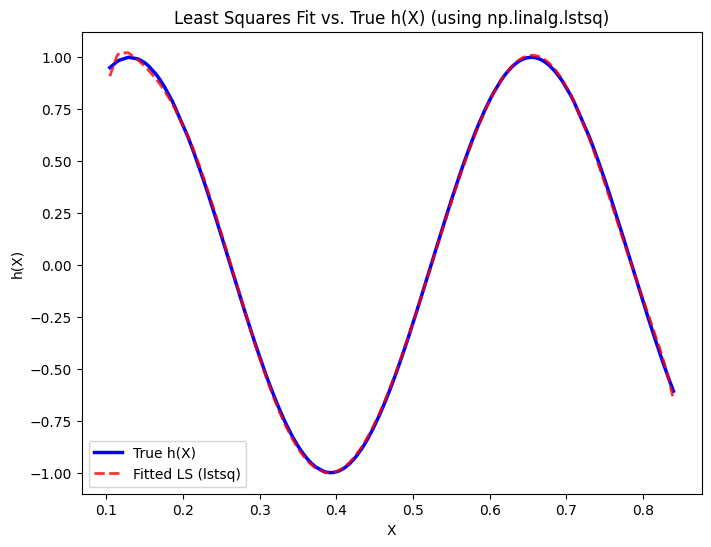

In [6]:
h_fun = lambda x: np.sin(12 * x)  # Example custom function
n = 30
K = 10
M = 10
step_size = 0.05
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, step_size = step_size, pZ_effect = 1)
X = data["X"]
# Compute the true function values
h_X = data["h_fun"](X)  # True values of h(X)

# Compute the density matrix
density_matrix = data["density_X_given_Z"](X)  # Shape: (N, K)
density_matrix_marginal = np.mean(density_matrix, axis = 1)
density_matrix_norm = density_matrix / density_matrix_marginal[:, None]

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(density_matrix_norm, h_X, rcond=None)  # Least-squares solution

# Compute fitted values
h_X_fitted = density_matrix_norm @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
h_X_sorted = h_X[sort_idx]
h_X_fitted_sorted = h_X_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, h_X_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True h(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()

## Riesz representer

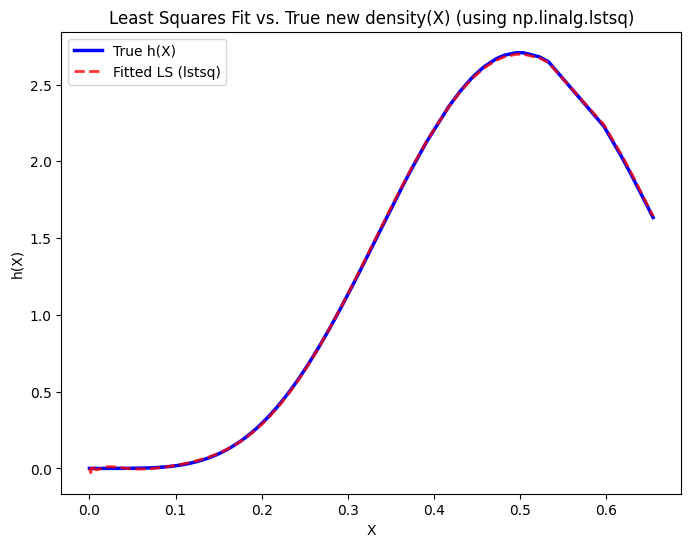

In [7]:
n = 30
K = 10
M = 10
step_size = 0.05
ab_new = [6,6]
data = generate_data(h_fun=h_fun, n=n, K=K, M = M, ab_new = ab_new, step_size = step_size, pZ_effect = 1)
X = data["X"]


 
# Compute the density matrix
density_matrix = data["density_X_given_Z"](X)  # Shape: (N, K)
density_new = data["density_new"](X)  # Shape: (N, 1)

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(density_matrix, density_new, rcond=None)  # Least-squares solution

# Compute fitted values
density_new_fitted = density_matrix @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]
density_new_sorted = density_new[sort_idx]
density_new_fitted_sorted = density_new_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, density_new_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, density_new_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True new density(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()

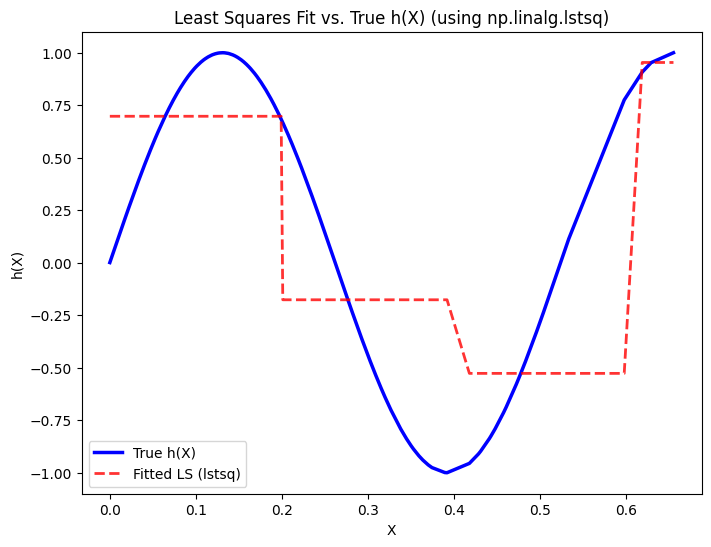

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def generate_basis_functions(epsilon=0.05, J=None, L=1):
    """
    Generates step function basis functions x -> 1(x > t) with knots in [0,1].
    If J is not provided, it is determined by ensuring an L-Lipschitz function 
    can be approximated within error epsilon.

    Parameters:
        epsilon : float, optional (default=0.05)
            The maximum allowable approximation error for an L-Lipschitz function.
        J : int, optional
            The number of basis functions (knots). If None, it is computed from epsilon.
        L : float, optional (default=1)
            The Lipschitz constant of the function to approximate.

    Returns:
        knots : np.array, shape (J,)
            The knot points in [0,1].
    """
    # Compute J if not given
    if J is None:
        J = max(1,int(np.ceil(L / (2 * epsilon))))

    # Create J equally spaced knot points in (0,1)
    knots = np.linspace(0, 1, J + 2)[:-1]  # Avoid endpoints 0 and 1    
 
    return knots

def construct_design_matrix(X, knots):
    """
    Constructs a design matrix for the step function basis on input X.

    Parameters:
        X : np.array, shape (N,)
            Input data points.
        knots : np.array, shape (J,)
            Knot points for the basis functions.

    Returns:
        design_matrix : np.array, shape (N, J)
            The design matrix where each column corresponds to 1(X > t_j).
    """
    return (X[:, None] > knots).astype(float)

# --- Main Execution ---

# Get data
X = data['X']  # Compute the true function values
h_X = data["h_fun"](X)  # True values of h(X)
n = len(X)
# Generate basis functions
knots = generate_basis_functions(n**(-1/3))

# Construct design matrix
X_basis = construct_design_matrix(X, knots)  # FIXED FUNCTION CALL

# Solve least squares problem using np.linalg.lstsq
beta_star, _, _, _ = np.linalg.lstsq(X_basis, h_X, rcond=None) 

# Compute fitted values
h_X_fitted = X_basis @ beta_star  # Predicted values

# Sort data for smooth plotting
sort_idx = np.argsort(X)  # FIXED VARIABLE NAME
X_sorted = X[sort_idx]  # FIXED REFERENCE TO X
h_X_sorted = h_X[sort_idx]
h_X_fitted_sorted = h_X_fitted[sort_idx]

# --- Plotting ---
plt.figure(figsize=(8, 6))

# True function (Solid Blue Line)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='blue', linewidth=2.5)

# Fitted LS function (Dashed Red Line)
plt.plot(X_sorted, h_X_fitted_sorted, label="Fitted LS (lstsq)", linestyle='dashed', color='red', linewidth=2, alpha=0.8)

# Labels & Legend
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Least Squares Fit vs. True h(X) (using np.linalg.lstsq)")
plt.legend()
plt.show()


# Fitting nuisance functions

In [26]:
# settings
freq = 6
h_fun = lambda x: 0.5*(freq*x)  + np.sin(freq * x)
L = freq  # Lipschitz constant
n = 50
K = 1000
M = 10
step_size = 0.2

## Fit structural function NPIV

Gamma: 1.00e-01, Lambda: 1.00e-01, Risk: -2.393930, Quad term: 0.194793,  break: 0.000000
Split: -2.393930, Split: -2.394464
inf 0
Gamma: 1.00e-01, Lambda: 4.28e-02, Risk: -2.411852, Quad term: 0.217130,  break: 0.000000
Split: -2.411852, Split: -2.412506
0.01792217368075466 inf
Gamma: 1.00e-01, Lambda: 1.83e-02, Risk: -2.415968, Quad term: 0.227911,  break: 0.000000
Split: -2.415968, Split: -2.416707
0.004115744233027296 0.01792217368075466
Gamma: 1.00e-01, Lambda: 7.85e-03, Risk: -2.416938, Quad term: 0.232779,  break: 0.000000
Split: -2.416938, Split: -2.417723
0.0009702631693655484 0.004115744233027296
Gamma: 1.00e-01, Lambda: 3.36e-03, Risk: -2.417196, Quad term: 0.234912,  break: 0.000000
Split: -2.417196, Split: -2.418001
0.00025744011600137284 0.0009702631693655484
Gamma: 1.00e-01, Lambda: 1.44e-03, Risk: -2.417276, Quad term: 0.235835,  break: 0.000000
Split: -2.417276, Split: -2.418091
8.018542805210416e-05 0.00025744011600137284
Gamma: 1.00e-01, Lambda: 6.16e-04, Risk: -2.41

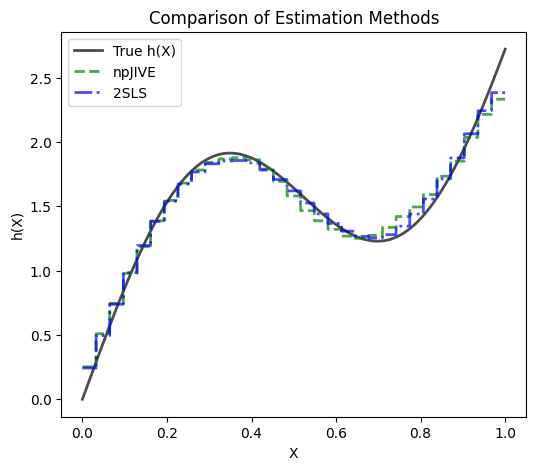

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.utils import *
from discreteNPIV.solve_primal_structural import *
from discreteNPIV.npiv_2SLS import *
from discreteNPIV.solve_primal_npJIVE_original import *



# Generate synthetic data for model fitting and evaluation
data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1)
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

data_eval = generate_data(h_fun=h_fun, n=500, K=K, M=M, step_size=step_size, pZ_effect=1)
folds_eval = make_cross_folds(data_eval['Z'])

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=L)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_structural(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_primal_risk(h_hat_val_npiv, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_structural(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_primal_risk(h_hat_val_jive, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_primal_risk(h_hat_val_2sls, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure(figsize=(6, 5))

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()










 



Gamma: 1.00e-01, Lambda: 1.00e-01, Risk: -2.231442, Quad term: 0.181611,  break: 0.000000
Split: -2.231442, Split: -2.232032
inf 0
Gamma: 1.00e-01, Lambda: 4.28e-02, Risk: -2.248591, Quad term: 0.202595,  break: 0.000000
Split: -2.248591, Split: -2.249226
0.01714862601399947 inf
Gamma: 1.00e-01, Lambda: 1.83e-02, Risk: -2.252568, Quad term: 0.212736,  break: 0.000000
Split: -2.252568, Split: -2.253263
0.003977436984032412 0.01714862601399947
Gamma: 1.00e-01, Lambda: 7.85e-03, Risk: -2.253518, Quad term: 0.217320,  break: 0.000000
Split: -2.253518, Split: -2.254249
0.0009496644745410343 0.003977436984032412
Gamma: 1.00e-01, Lambda: 3.36e-03, Risk: -2.253774, Quad term: 0.219329,  break: 0.000000
Split: -2.253774, Split: -2.254524
0.0002558733302211458 0.0009496644745410343
Gamma: 1.00e-01, Lambda: 1.44e-03, Risk: -2.253854, Quad term: 0.220198,  break: 0.000000
Split: -2.253854, Split: -2.254613
8.085275919400559e-05 0.0002558733302211458
Gamma: 1.00e-01, Lambda: 6.16e-04, Risk: -2.2538

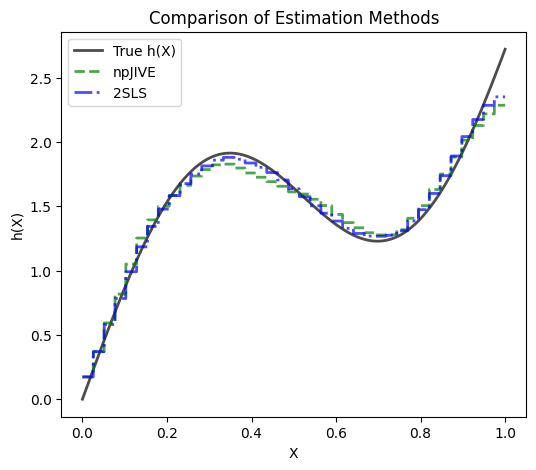

Time to compute fold means: 1.278615 seconds
Time for select tunings: 0.453342 seconds

Selected Parameters and Risks:
----------------------------------------
npJIVE:
  Lambda: 1.13e-04
  Gamma:  5.99e-04
  Risk:   0.00000247
----------------------------------------
2SLS:
  Lambda: 2.07e-05
  Gamma:  2.15e-03
  Risk:   -0.00011411
----------------------------------------
Using npJIVE: No
NPIV Risk: 0.00926509023223582
condioning before:  5806509.257774952 -0.0004743544715918491
npJIVE Risk: 0.010395983886499217
2SLS Risk: 0.00926509023223582


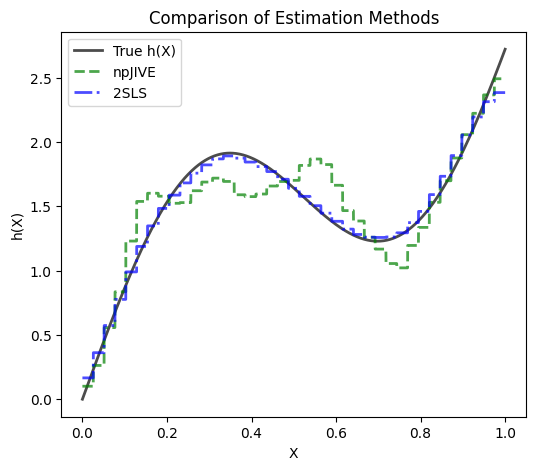

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.utils import *
from discreteNPIV.solve_primal_structural import *
from discreteNPIV.npiv_2SLS import *
from discreteNPIV.solve_primal_npJIVE_original import *



# Generate synthetic data for model fitting and evaluation
data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1)
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

data_eval = generate_data(h_fun=h_fun, n=500, K=K, M=M, step_size=step_size, pZ_effect=1)
folds_eval = make_cross_folds(data_eval['Z'])

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=L)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_structural(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_primal_risk(h_hat_val_npiv, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_structural(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_primal_risk(h_hat_val_jive, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_primal_risk(h_hat_val_2sls, data_eval['Z'], data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure(figsize=(6, 5))

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

#plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()










 
from discreteNPIV.solve_primal_npJIVE_original import *
 

 
# ---- NPIV Primal (Using CV to choose between npJIVE and 2SLS) ----
np.random.seed(123)
theta_hat, _, cv_output = npiv_primal(X_basis, Z, Y, K, n_splits=10, num_lambda=20, num_gamma=10, verbose=True)
params_jive, params_2sls, use_npjiv, cross_folds = cv_output

h_hat_npiv = X_basis @ theta_hat
h_hat_val_npiv = construct_design_matrix(data_eval['X'], knots) @ theta_hat
risk_npiv = np.sqrt(compute_JIVE_risk(h_hat_val_npiv, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("NPIV Risk:", risk_npiv)

# ---- npJIVE Fit ----
theta_hat_jive, _ = solve_primal_npJIVE(
    X_basis, Z, Y, K, cross_folds=cross_folds,
    lambda_K=params_jive['lambda'], gamma=params_jive['gamma'],
    project_PD=False, num_repeats=10
)
h_hat_jive = X_basis @ theta_hat_jive
h_hat_val_jive = construct_design_matrix(data_eval['X'], knots) @ theta_hat_jive
risk_jive = np.sqrt(compute_JIVE_risk(h_hat_val_jive, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("npJIVE Risk:", risk_jive)

# ---- 2SLS Fit ----
theta_hat_2sls, h_fun_init = solve_primal_structural_2SLS(
    X_basis, Z, Y, K, lambda_K=params_2sls['lambda'], gamma=params_2sls['gamma']
)
h_hat_2sls = X_basis @ theta_hat_2sls
h_hat_val_2sls = construct_design_matrix(data_eval['X'], knots) @ theta_hat_2sls
risk_2sls = np.sqrt(compute_JIVE_risk(h_hat_val_2sls, data_eval['Z'], _, data_eval['Y'], folds_eval, K))
print("2SLS Risk:", risk_2sls)

# ---- Plot all methods together ----
plt.figure(figsize=(6, 5))

# Sort X and corresponding values
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
h_X_sorted = h_X[sorted_indices]
h_hat_npiv_sorted = h_hat_npiv[sorted_indices]
h_hat_jive_sorted = h_hat_jive[sorted_indices]
h_hat_2sls_sorted = h_hat_2sls[sorted_indices]

#plt.plot(X_sorted, h_hat_npiv_sorted, label="NPIV Primal", color='red', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_X_sorted, label="True h(X)", color='black', alpha=0.7, linewidth=2)
plt.plot(X_sorted, h_hat_jive_sorted, label="npJIVE", color='green', alpha=0.7, linewidth=2, linestyle='dashed')
plt.plot(X_sorted, h_hat_2sls_sorted, label="2SLS", color='blue', alpha=0.7, linewidth=2, linestyle='dashdot')

plt.legend()
plt.xlabel("X")
plt.ylabel("h(X)")
plt.title("Comparison of Estimation Methods")
plt.show()



## Fit debiasing nuisance

In [93]:
import numpy as np
import matplotlib.pyplot as plt


def make_T(data, n = 10_000):
    """
    Constructs an operator T that maps a function h_fun to a vector 
    of conditional expectations E[h(X) | Z = k] for each k.

    Parameters:
        data : dict
            Contains 'K', 'M', 'a_params', 'b_params', and 'delta'.

    Returns:
        T_adjoint : function
            Function that takes h_fun (a function) and returns a vector of length K, 
            where each element is E[h(X) | Z = k].
    """
    # Retrieve parameters
  # Large sample for Monte Carlo estimation
    K, M = data['K'], data['M']
    a_params, b_params, delta = data['a_params'], data['b_params'], data['delta']
    
    # Generate samples for Monte Carlo estimation
    Z = np.repeat(np.arange(K), n)

    # Generate individual-level confounder U
    U_levels = np.linspace(-1, 1, M)
    probs = np.full(M, 1 / M)  # Equal probabilities
    U = np.random.choice(U_levels, size=n * K, p=probs)

    # Compute confounded beta parameters
    a_confounded = a_params[Z] * np.exp(delta * U)
    b_confounded = b_params[Z] * np.exp(- delta * U)

    # Sample X | Z, U ~ Beta(a_confounded, b_confounded)
    X = beta.rvs(a_confounded, b_confounded)

    # Define  T
    def T_(h_fun):
        """
        Given a function h_fun, compute the conditional expectation E[h(X) | Z = k] 
        for each k using Monte Carlo integration.

        Parameters:
            h_fun : function
                A function that takes scalar input x and outputs h(x).

        Returns:
            E_h_given_Z : np.array, shape (K,)
                Estimated conditional expectation E[h(X) | Z = k].
        """
        h_X = h_fun(X)  # Direct function application

        # Vectorized computation of E[h(X) | Z = k] using np.bincount
        sum_hX = np.bincount(Z, weights=h_X, minlength=K)  # Sum of h(X) per group
        count_Z = np.bincount(Z, minlength=K)  # Count of samples per group
        
        # Compute the conditional expectation, handling zero-division
        E_h_given_Z = np.divide(sum_hX, count_Z, where=(count_Z > 0))  # Avoid division by zero
        
        return E_h_given_Z

    return T_



from scipy.interpolate import interp1d
 

def make_T_adjoint(data, x_grid = None, n_grid=100, p_Z=None):
    """
    Constructs an adjoint operator T_adjoint that maps a vector q of length K
    to a function T_adjoint(q)(x), which represents the transformed function.

    Parameters:
        data : dict
            Must contain 'density_X_given_Z', which is a function that returns P(X | Z).
        x_grid : array_like, optional
            Grid of x values to evaluate densities. Defaults to 200 points in [0,1].
        p_Z : array_like, optional
            Prior probability of Z (shape (K,)). Defaults to uniform if not provided.

    Returns:
        function: T_adjoint(q), which returns an interpolated function.
    """
    density_X_given_Z = data['density_X_given_Z']

    if x_grid is None:
        x_grid = np.linspace(0, 1, n_grid)

    P = density_X_given_Z(x_grid)  # Shape: (n, K)
    
    K = P.shape[1]
    if p_Z is None:
        p_Z = np.full(K, 1/K)  # Uniform prior over Z

    # Compute marginal density P(X) = sum_z P(X | Z) P(Z)
    p_marginal = P @ p_Z  # Shape: (n,)

    # Handle division by zero: set 0/0 to 0
    with np.errstate(divide='ignore', invalid='ignore'):
        T_adjoint_matrix = np.where(p_marginal[:, None] != 0, (P * p_Z) / p_marginal[:, None], 0)

    # Define the T_adjoint operator
    def T_adjoint(q):
        """
        Applies the adjoint operator to q (length K), returning an interpolated function.

        Parameters:
            q : array_like, shape (K,)
                A vector of length K.

        Returns:
            function: T_adj_q(x), an interpolated function.
        """
        if q.shape[0] != T_adjoint_matrix.shape[1]:
            raise ValueError(f"q must have length {T_adjoint_matrix.shape[1]}, got {q.shape[0]}.")

        T_adj_q_grid = T_adjoint_matrix @ q  # Shape: (n,)

        return interp1d(x_grid, T_adj_q_grid, kind='linear', fill_value="extrapolate")

    return T_adjoint, T_adjoint_matrix, x_grid, p_marginal


 
import numpy as np
from scipy.stats import gaussian_kde

def estimate_marginal_density(X):
    X = np.array(X).reshape(-1)

    # Use Gaussian KDE with automatic bandwidth selection (Scott's rule by default)
    kde = gaussian_kde(X)  

    # Evaluate the density estimate at the input points
    density_marginal = kde.evaluate(X)

    return density_marginal


 

Gamma: 1.00e-01, Lambda: 1.00e-01, Risk: -1.425256, Quad term: 0.092932,  break: 0.000000
Split: -1.425256, Split: -1.384230
inf 0
Gamma: 1.00e-01, Lambda: 2.64e-02, Risk: -1.559817, Quad term: 0.111716,  break: 0.000000
Split: -1.559817, Split: -1.490721
0.13456103344538461 inf
Gamma: 1.00e-01, Lambda: 6.95e-03, Risk: -1.608397, Quad term: 0.118307,  break: 0.000000
Split: -1.608397, Split: -1.526955
0.048579882890413595 0.13456103344538461
Gamma: 1.00e-01, Lambda: 1.83e-03, Risk: -1.622571, Quad term: 0.120222,  break: 0.000000
Split: -1.622571, Split: -1.537323
0.014173995506291392 0.048579882890413595
Gamma: 1.00e-01, Lambda: 4.83e-04, Risk: -1.626415, Quad term: 0.120741,  break: 0.000000
Split: -1.626415, Split: -1.540119
0.0038443453571290753 0.014173995506291392
Gamma: 1.00e-01, Lambda: 1.27e-04, Risk: -1.627437, Quad term: 0.120878,  break: 0.000000
Split: -1.627437, Split: -1.540861
0.0010213205561870886 0.0038443453571290753
Gamma: 1.00e-01, Lambda: 3.36e-05, Risk: -1.627707

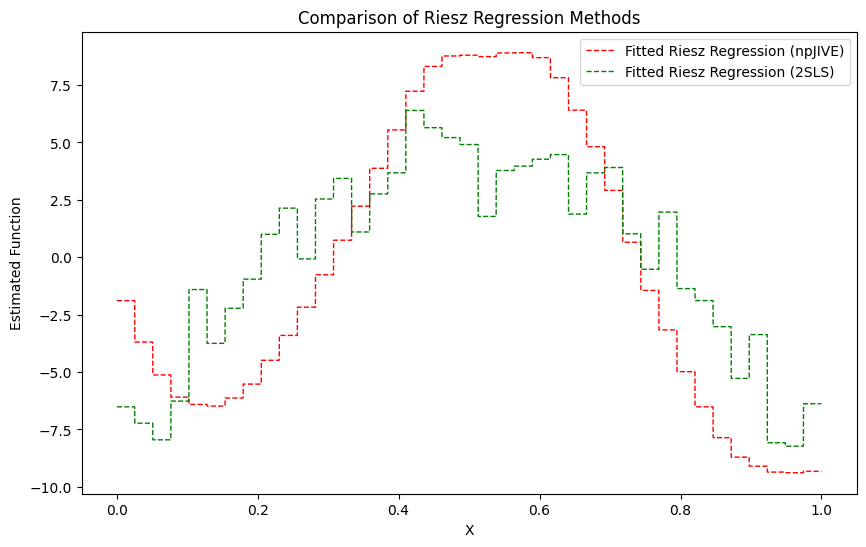

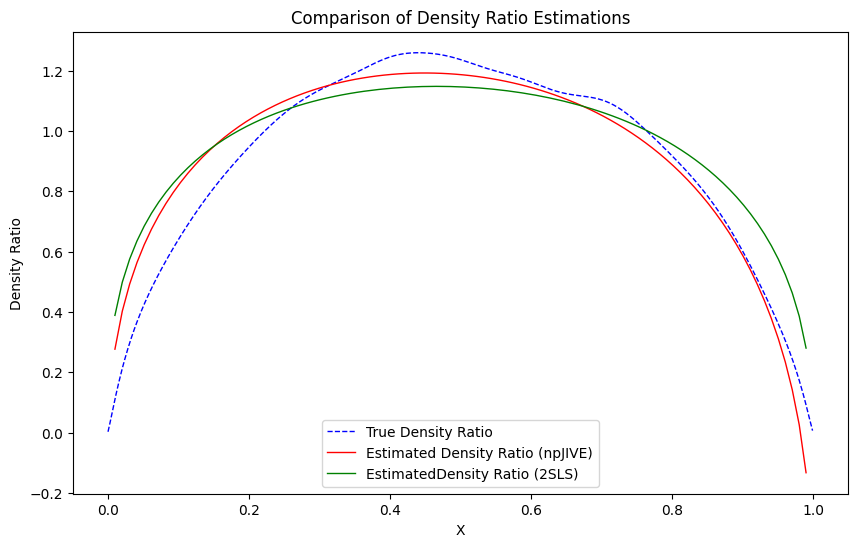

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_dual_riesz import *
from discreteNPIV.npiv_2SLS import *

# Generate synthetic data
n = 30
K = 2000
step_size = 0.3
#data = generate_data(h_fun=None, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[2.5, 2.5])
Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
h_X = data["h_fun"](X)  # True values of h(X)
N = len(X)

# Generate basis functions
knots = generate_basis_functions(K**(-1/3), L=6)
X_basis = construct_design_matrix(X, knots)
X_new_basis = construct_design_matrix(X_new, knots)

# ---- Dual Riesz Estimation (npJIVE) ----
cv_output = cross_validate_dual(
    X_basis, Z, K, X_new_basis, num_lambda=20, num_gamma=20, verbose=True
)
cv_output = params_jive, params_2sls, use_npjiv, cross_folds = cv_output
 

b_hat, _ = solve_dual_riesz(X_basis, Z, K, X_new_basis, lambda_K=params_jive['lambda'], gamma=params_jive['gamma'])

# Define function for predictions
def beta_fun(X):
    X_basis = construct_design_matrix(X, knots)
    return X_basis @ b_hat

 
 

b_hat_2sls, _ = solve_dual_riesz_2SLS(X_basis, Z, K, X_new_basis,  params_2sls['lambda'], gamma=params_2sls['gamma'])

def beta_fun_2sls(X):
    X_basis = construct_design_matrix(X, knots)
    return X_basis @ b_hat_2sls

# ---- Combined Plot: Riesz Regression (npJIVE & 2SLS) ----
sort_idx = np.argsort(X)
X_sorted = X[sort_idx]


plt.figure(figsize=(10, 6))
plt.plot(X_sorted, beta_fun(X_sorted), label="Fitted Riesz Regression (npJIVE)", linestyle='dashed', color='red', linewidth=1)
plt.plot(X_sorted, beta_fun_2sls(X_sorted), label="Fitted Riesz Regression (2SLS)", linestyle='dashed', color='green', linewidth=1)
plt.legend()
plt.xlabel("X")
plt.ylabel("Estimated Function")
plt.title("Comparison of Riesz Regression Methods")
plt.show()
 



# ---- Density Ratio Estimation ----
X_sampled = X[np.random.choice(X.shape[0], 5000, replace=False)]
density_marginal = estimate_marginal_density(X_sampled)
density_new = data["density_new"](X_sampled)
density_ratio = density_new.reshape(-1) / density_marginal.reshape(-1)

# Sort for plotting'


#density_matrix = data["density_X_given_Z"](X)
T_fun = make_T(data)
Tadj_fun, T_adjoint_matrix, x_grid, p_marginal = make_T_adjoint(data)
dr_jive = Tadj_fun(T_fun(beta_fun))(X)
dr_2sls = Tadj_fun(T_fun(beta_fun_2sls))(X)


sort_idx = np.argsort(X_sampled)
X_sorted = X_sampled[sort_idx]
density_ratio_sorted = density_ratio[sort_idx]

sort_idx = np.argsort(X)
X_sorted_full = X[sort_idx]
dr_jive_sorted = dr_jive[sort_idx]
dr_2sls_sorted = dr_2sls[sort_idx]


 

plt.figure(figsize=(10, 6))
plt.plot(X_sorted, density_ratio_sorted, label="True Density Ratio", linestyle='dashed', color='blue', linewidth=1)
plt.plot(X_sorted_full, dr_jive_sorted, label="Estimated Density Ratio (npJIVE)", linestyle='solid', color='red', linewidth=1)
plt.plot(X_sorted_full, dr_2sls_sorted, label="EstimatedDensity Ratio (2SLS)", linestyle='solid', color='green', linewidth=1)
plt.xlabel("X")
plt.ylabel("Density Ratio")
plt.title("Comparison of Density Ratio Estimations")
plt.legend()
plt.show()

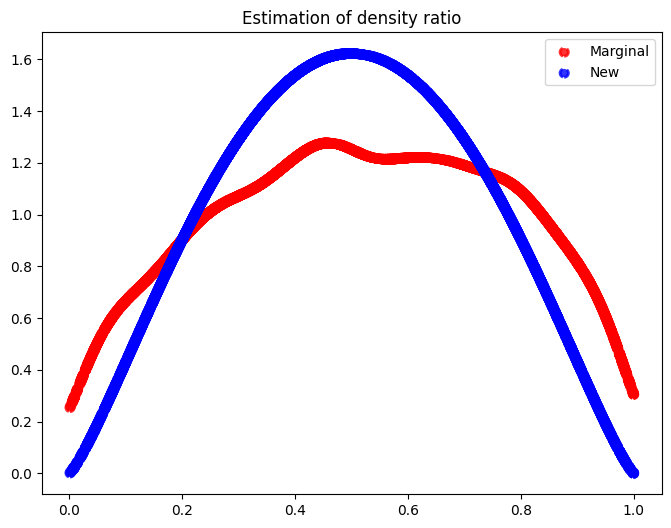

In [79]:
 

X_sampled = X[np.random.choice(X.shape[0], 5000, replace=False)]
density_marginal =  estimate_marginal_density(X_sampled) 
density_new = data["density_new"](X_sampled)
density_ratio = density_new.reshape(-1) / density_marginal.reshape(-1)
sort_idx = np.argsort(X_sampled)
X_sorted = X_sampled[sort_idx]
density_ratio_sorted = density_ratio[sort_idx]

 


plt.figure(figsize=(8, 6))


# Fitted LS function (Dashed Red Line)
plt.scatter(X_sampled,  density_marginal, label="Marginal", linestyle='dashed', color='red', linewidth=2, alpha=0.8)
plt.scatter(X_sampled,  density_new, label="New", linestyle='dashed', color='blue', linewidth=2, alpha=0.8)
plt.title("Estimation of density ratio")
plt.legend()
plt.show()





# Estimating linear functional

## IPW estimation

0
1.855731119833006 1.7944406142429683 1.842258691645426
1
1.8575816404512944 1.810026517055392 1.8549944338476472
2
1.8574840730346918 1.7878773373095806 1.8375491503998946
3
1.8553828796223633 1.8728554564368713 1.860398688296132
4
1.855843289587892 1.8059462954216585 1.830191833072648
5
1.8558284888906444 1.8865083785011603 1.8208593777445976
6
1.8559800230583017 1.787262794630279 1.8564909150557214
7
1.8566698640742583 1.805126842355857 1.8493488090196657
8
1.8556451008934864 1.8210351090144083 1.8297174083052863
9
1.8552195148503274 1.8344825523189425 1.8529417541932203
10
1.8542955710520947 1.8515178738135094 1.8634119350267664
11
1.8578310330077121 1.8413859462850495 1.8409898147584056
12
1.8559792215971453 1.8380116870418648 1.859061680706877
13
1.857394915891726 1.8782444050169897 1.8630046617257663
14
1.8566273314879105 1.8387746140586134 1.8529657644245259
15
1.85713663750857 1.8460446447101555 1.8608509074865385
16
1.856478700943954 1.778110647594667 1.8247038420195683
17
1

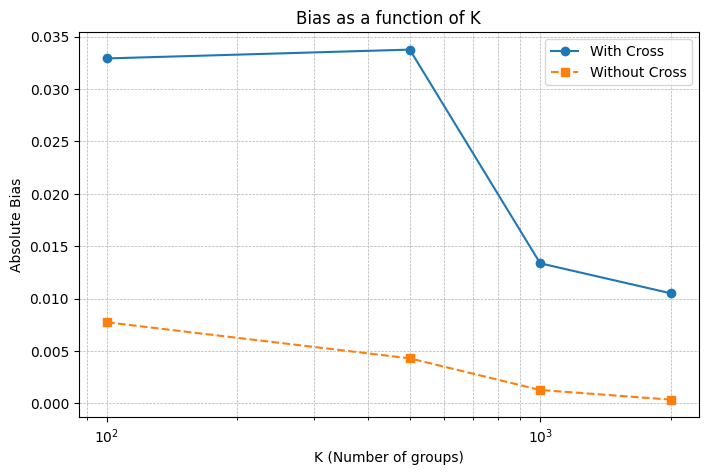

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_dual_riesz import *
from discreteNPIV.utils import *
from discreteNPIV.npiv_2SLS import *

def compute_bias(K, MC_reps=100, n=30, M=10, step_size=0.2, freq=6, seed = 123):
    h_fun = lambda x: 0.6 * (freq*x)  + np.sin(freq * x)
    estimates_IPW = []
    estimates_IPW_no_cross = []
    estimates_truth = []
    
    for mc in range(MC_reps):
        print(mc)
        data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[2.5, 2.5], seed_main=seed    , seed_new=seed   )
        #data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[3,3], seed_main=None  , seed_new=None )
        Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
        h_X = data['h_fun'](X)
        
        knots = generate_basis_functions(K**(-1/3), L=freq)
        X_basis = construct_design_matrix(X, knots) 
        X_new_basis = construct_design_matrix(X_new, knots) 
        
        # ---- Dual Riesz Estimation (npJIVE) ----
        cv_output = cross_validate_dual(
            X_basis, Z, K, X_new_basis, num_lambda=20, num_gamma=20, verbose=False
        )
        cv_output = params_jive, params_2sls, use_npjiv, cross_folds = cv_output
 

        b_hat, _ = solve_dual_riesz(X_basis, Z, K, X_new_basis, lambda_K=params_jive['lambda'], gamma=params_jive['gamma'])
        beta_hat = X_basis @ b_hat

        n_total = len(Z)
        group_counts = np.bincount(Z, minlength=K)
        W = group_counts / n_total
        q_hat_0 = compute_group_means(beta_hat, Z, cross_folds, 0, K)
        q_hat_1 = compute_group_means(beta_hat, Z, cross_folds, 1, K)
        T_Y_1 = compute_group_means(Y, Z, cross_folds, 1, K)
        T_Y_0 = compute_group_means(Y, Z, cross_folds, 0, K)
        
        est_IPW = (np.sum(W * q_hat_0 * T_Y_1) + np.sum(W * q_hat_1 * T_Y_0)) / 2
        estimates_IPW.append(est_IPW)
 
 

        b_hat, _ = solve_dual_riesz_2SLS(X_basis, Z, K, X_new_basis,  params_2sls['lambda'], gamma=params_2sls['gamma'])
        beta_hat = X_basis @ b_hat
        q_hat = compute_group_means(beta_hat, Z, np.zeros_like(Z), 0, K)
        T_Y = compute_group_means(Y, Z, np.zeros_like(Z), 0, K)
        truth = np.mean(h_fun(X_new))
        est_IPW_no_cross = np.sum(W * q_hat * T_Y) 
        estimates_IPW_no_cross.append(est_IPW_no_cross)
        estimates_truth.append(truth)
        print(truth, est_IPW, est_IPW_no_cross)
    
     
    absolute_bias = np.abs(np.mean(np.array(estimates_IPW) - np.array(estimates_truth)))
    absolute_bias_no_cross = np.abs(np.mean(np.array(estimates_IPW_no_cross) - np.array(estimates_truth)))  
    return absolute_bias, absolute_bias_no_cross

import matplotlib.pyplot as plt

# Define values of K to test
K_values = [100, 500, 1000, 2000]
bias_values = [compute_bias(K) for K in K_values]  # Assuming compute_bias(K) returns a tuple or list
bias_values_cross = [b[0] for b in bias_values]  # Extract first value (cross)
bias_values_no_cross = [b[1] for b in bias_values]  # Extract second value (no cross)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="With Cross", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Without Cross", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")  # Use log scale for better visualization
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()



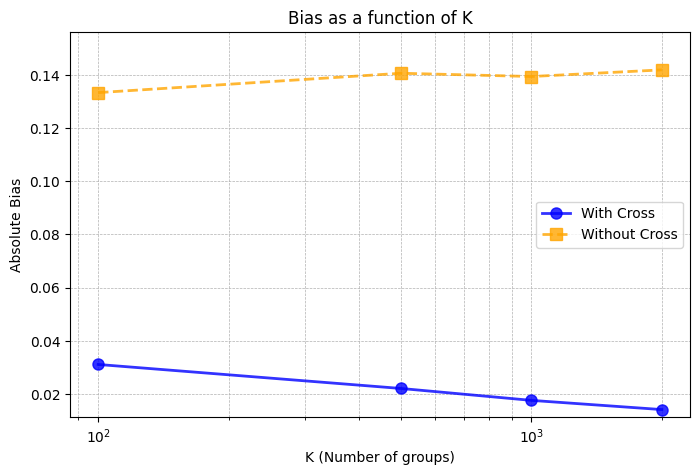

In [13]:
import matplotlib.pyplot as plt

# Extract first value (cross) and second value (no cross)
bias_values_cross = [b[0] for b in bias_values]  
bias_values_no_cross = [b[1] for b in bias_values]  

# Create figure
plt.figure(figsize=(8, 5))

# Plot with modifications
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="With Cross", 
         markersize=8, linewidth=2, color='blue', alpha=0.8)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Without Cross", 
         markersize=8, linewidth=2, color='orange', alpha=0.8)

# Set y-axis limits for better visibility
plt.ylim(min(bias_values_cross) * 0.8, max(bias_values_no_cross) * 1.1)  

# Log scale for x-axis
plt.xscale("log")

# Labels and title
plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")

# Grid for better readability
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Show legend
plt.legend()

# Show the plot
plt.show()


## Plug-in estimation

In [269]:
import numpy as np
import matplotlib.pyplot as plt
from discreteNPIV.solve_primal_npJIVE import *
from discreteNPIV.utils import *
from discreteNPIV.naive_npiv import *

def compute_bias(K, MC_reps=200, n=50, M=10, step_size=0.2, freq=6, seed = 536):
    h_fun = lambda x: 0.8 * (freq*x)  + np.sin(freq * x)
    estimates = []
    estimates_no_cross = []
    estimates_truth = []
    strong_norms = []
    strong_norms_no_cross = []
    lambda_grid = np.logspace(-2, -6, 30)  
    gamma_grid = np.logspace(-3, -6, 20)
    lambda_grid = [1e-5]
    gamma_grid = [0.00045]
    L = 3

    
    for mc in range(MC_reps):
        print(mc)
        data = generate_data(h_fun=h_fun, n=n, K=K, M=M, step_size=step_size, pZ_effect=1, range_ab=(1,3), ab_new=[3,3], seed_main=seed + mc, seed_new=seed + mc)
        Z, X, Y, X_new = data['Z'], data['X'], data['Y'], data['X_new']
        h_X = data['h_fun'](X)
        
        knots = generate_basis_functions(K**(-1/3), L=L)
        X_basis = construct_design_matrix(X, knots) 
        X_basis_new = construct_design_matrix(X_new, knots) 
        
        #np.random.seed(123)
        #best_lambda, best_gamma, cross_folds = cross_validate_JIVE_slow(X_basis, Z, Y, K, num_lambda=20, num_gamma=10, verbose=False, num_repeats=1)
        #print(best_lambda, best_gamma)
        #np.random.seed(123)
        best_lambda, best_gamma, cross_folds = cross_validate_JIVE(X_basis, Z, Y, K, lambda_grid = lambda_grid, gamma_grid = gamma_grid, verbose=True)
        print(best_lambda, best_gamma)
         
        b_hat, _ = solve_primal_npJIVE(X_basis, Z, Y, K, cross_folds=cross_folds, lambda_K=best_lambda, gamma=best_gamma, num_repeats=1)
        h_hat_new = X_basis_new @ b_hat
        
        cross_folds = cross_folds[0]
        
        est_plugin = np.mean(h_hat_new)
        estimates.append(est_plugin)
        strong_norm = np.sqrt(np.mean((h_X - X_basis @ b_hat)**2))
        strong_norms.append(strong_norm)

        best_lambda, best_gamma = cross_validate_primal_no_cross(X_basis, Z, Y, K, num_lambda = 20, num_gamma = 5, verbose=False)
        print(best_lambda, best_gamma)
        b_hat, _ = solve_primal_no_cross(X_basis, Z, Y, K, lambda_K=best_lambda, gamma=best_gamma)
        h_hat_new = X_basis_new @ b_hat
        
        est_plugin_no_cross = np.mean(h_hat_new)
        estimates_no_cross.append(est_plugin_no_cross)
        strong_norm_no_cross = np.sqrt(np.mean((h_X - X_basis @ b_hat)**2))
        strong_norms_no_cross.append(strong_norm_no_cross)
        
        truth = np.mean(h_fun(X_new))
        estimates_truth.append(truth)

        print("estimates: ", truth, est_plugin, est_plugin_no_cross, strong_norm, strong_norm_no_cross) 
    
    estimates = np.array(estimates)
    estimates_no_cross = np.array(estimates_no_cross)
    estimates_truth = np.array(estimates_truth)
    
    # Compute bias
    absolute_bias = np.abs(np.mean(estimates - estimates_truth))
    absolute_bias_no_cross = np.abs(np.mean(estimates_no_cross - estimates_truth))  
    
    # Compute standard error
    se_with_cross = np.std(estimates - estimates_truth)  
    se_no_cross = np.std(estimates_no_cross - estimates_truth)  
    
    # Compute RMSE
    rmse_with_cross = np.sqrt(np.mean((estimates - estimates_truth) ** 2))
    rmse_no_cross = np.sqrt(np.mean((estimates_no_cross - estimates_truth) ** 2))

     
    
    return absolute_bias, se_with_cross, rmse_with_cross, absolute_bias_no_cross, se_no_cross, rmse_no_cross

# Define values of K to test
K_values = [ 2000]
bias_results = [compute_bias(K) for K in K_values]  # Assuming compute_bias(K) returns a tuple

bias_values_cross = [b[0] for b in bias_results]  # Bias with cross
se_values_cross = [b[1] for b in bias_results]  # SE with cross
rmse_values_cross = [b[2] for b in bias_results]  # RMSE with cross

bias_values_no_cross = [b[3] for b in bias_results]  # Bias without cross
se_values_no_cross = [b[4] for b in bias_results]  # SE without cross
rmse_values_no_cross = [b[5] for b in bias_results]  # RMSE without cross

# Plot the bias results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="Bias (With Cross)", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Bias (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

# Plot RMSE results
plt.figure(figsize=(8, 5))
plt.plot(K_values, rmse_values_cross, marker='o', linestyle='-', label="RMSE (With Cross)", markersize=6)
plt.plot(K_values, rmse_values_no_cross, marker='s', linestyle='--', label="RMSE (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


0
Time to compute fold means: 1.336790 seconds
Gamma: 4.50e-04, Lambda: 1.00e-05, Risk: 0.000363,  break: 0.000000
Gamma: 4.50e-04, Lambda: 1.00e-05, Risk: 0.000363
Time for select tunings: 0.008530 seconds

Selected Parameters and Risks:
----------------------------------------
npJIVE:
  Lambda: 1.00e-05
  Gamma:  4.50e-04
  Risk:   0.00036342
----------------------------------------
2SLS:
  Lambda: 1.00e-05
  Gamma:  4.50e-04
  Risk:   -0.00006030
----------------------------------------
Using npJIVE: No


ValueError: too many values to unpack (expected 3)

In [ ]:

# Plot the bias results
plt.figure(figsize=(8, 5))
plt.plot(K_values, bias_values_cross, marker='o', linestyle='-', label="Bias (With Cross)", markersize=6)
plt.plot(K_values, bias_values_no_cross, marker='s', linestyle='--', label="Bias (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Absolute Bias")
plt.title("Bias as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

# Plot SE results
plt.figure(figsize=(8, 5))
plt.plot(K_values, se_values_cross, marker='o', linestyle='-', label="SE (With Cross)", markersize=6)
plt.plot(K_values, se_values_no_cross, marker='s', linestyle='--', label="SE (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("SE")
plt.title("SE as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Plot RMSE results
plt.figure(figsize=(8, 5))
plt.plot(K_values, rmse_values_cross, marker='o', linestyle='-', label="RMSE (With Cross)", markersize=6)
plt.plot(K_values, rmse_values_no_cross, marker='s', linestyle='--', label="RMSE (Without Cross)", markersize=6)

plt.xlabel("K (Number of groups)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE as a function of K")
plt.xscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()
